In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='husl')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 5)

DATA_DIR = '../data/raw/ieee-fraud-detection'

In [2]:
# ── Load data ──────────────────────────────────────────────────────────────
print('Loading transaction data ...')
tx = pd.read_csv(f'{DATA_DIR}/train_transaction.csv')
id_ = pd.read_csv(f'{DATA_DIR}/train_identity.csv')

print(f'Transactions : {tx.shape}')
print(f'Identity     : {id_.shape}')

df = tx.merge(id_, on='TransactionID', how='left')
print(f'Merged       : {df.shape}')
print(f'Identity match rate: {id_["TransactionID"].isin(tx["TransactionID"]).sum() / len(tx):.1%}')

Loading transaction data ...
Transactions : (590540, 394)
Identity     : (144233, 41)
Merged       : (590540, 434)
Identity match rate: 24.4%


In [3]:
df.head(3)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Class Imbalance

Fraud rate: 3.4990%
Fraudulent:  20,663
Legitimate: 569,877


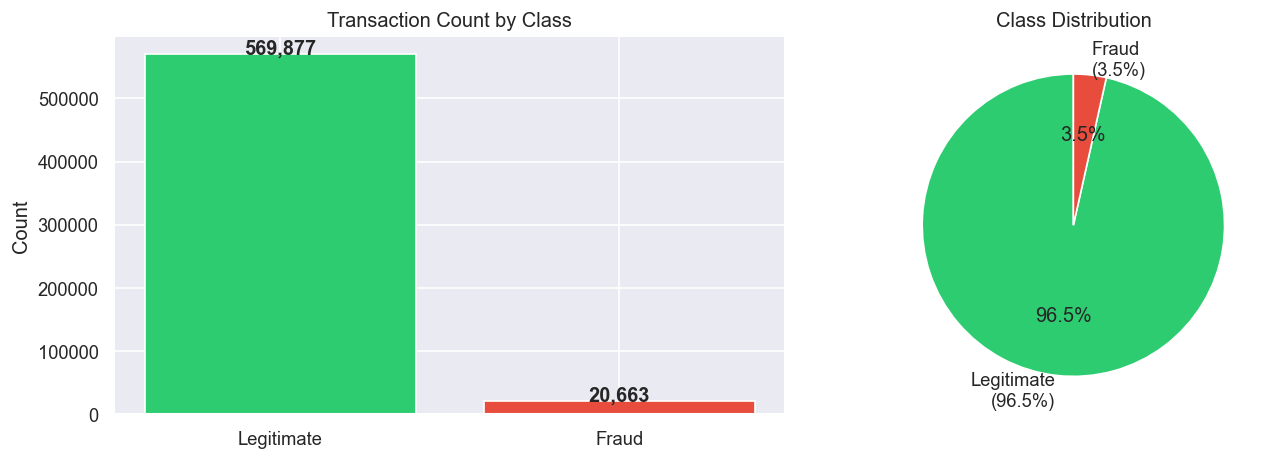

In [4]:
fraud_rate = df['isFraud'].mean()
print(f'Fraud rate: {fraud_rate:.4%}')
print(f'Fraudulent:  {df["isFraud"].sum():,}')
print(f'Legitimate: {(df["isFraud"]==0).sum():,}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
counts = df['isFraud'].value_counts()
ax1.bar(['Legitimate', 'Fraud'], counts.values, color=['#2ecc71', '#e74c3c'])
ax1.set_title('Transaction Count by Class')
ax1.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax1.text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

ax2.pie([1 - fraud_rate, fraud_rate],
        labels=['Legitimate\n(96.5%)', f'Fraud\n({fraud_rate:.1%})'],
        colors=['#2ecc71', '#e74c3c'],
        autopct='%1.1f%%',
        startangle=90)
ax2.set_title('Class Distribution')
plt.tight_layout()
plt.show()

## 2. Transaction Amount Analysis

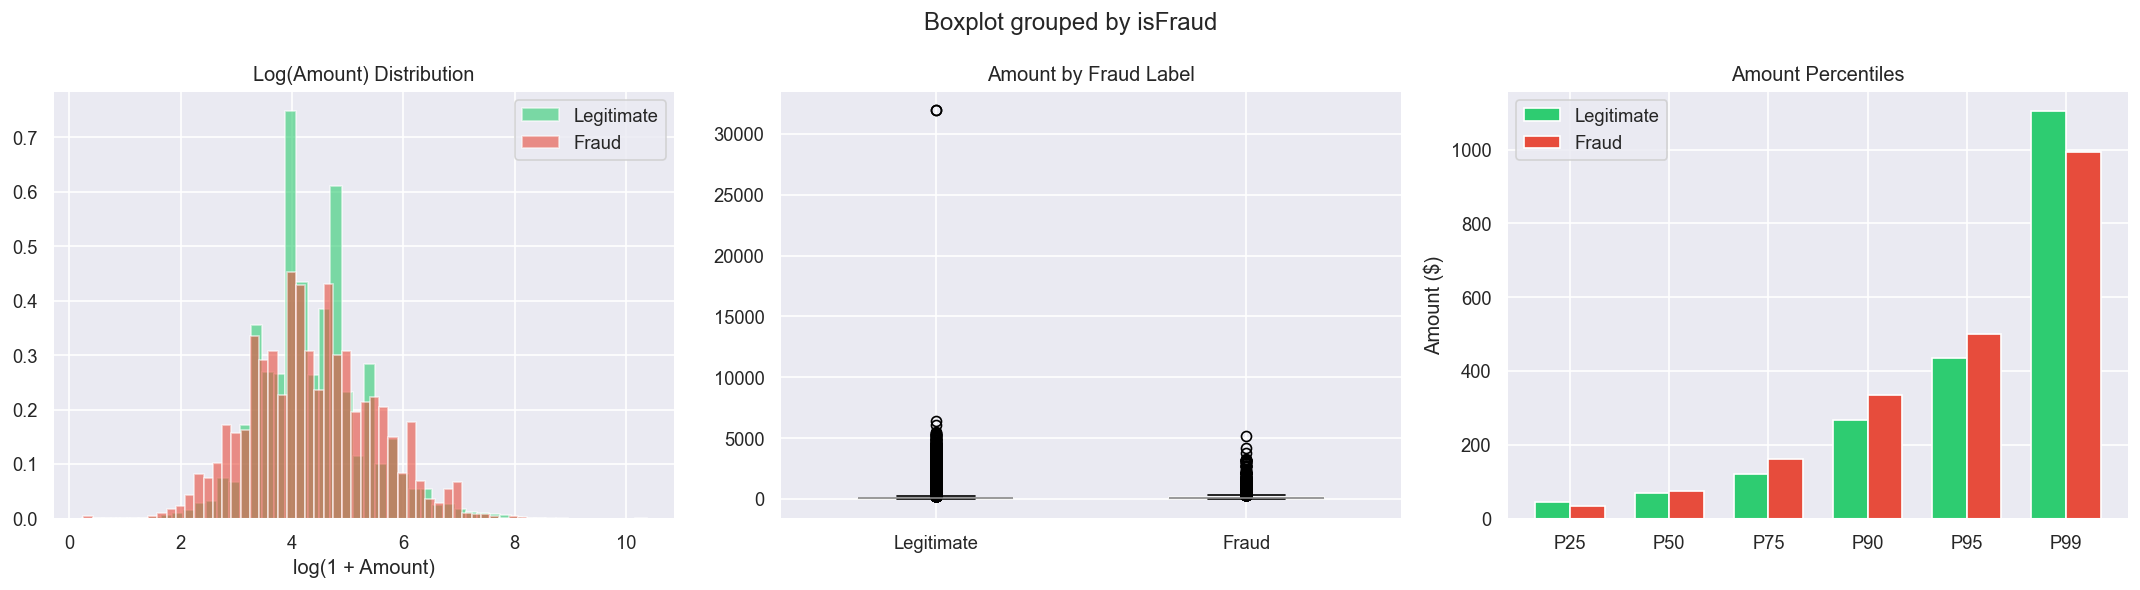


Amount Statistics by Class:
            count    mean     std   min    25%   50%    75%       max
isFraud                                                              
0        569877.0  134.51  239.40  0.25  43.97  68.5  120.0  31937.39
1         20663.0  149.24  232.21  0.29  35.04  75.0  161.0   5191.00


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Raw amount distribution (log scale)
for label, color, mask in [
    ('Legitimate', '#2ecc71', df['isFraud'] == 0),
    ('Fraud', '#e74c3c', df['isFraud'] == 1),
]:
    axes[0].hist(np.log1p(df.loc[mask, 'TransactionAmt']),
                 bins=50, alpha=0.6, label=label, color=color, density=True)
axes[0].set_title('Log(Amount) Distribution')
axes[0].set_xlabel('log(1 + Amount)')
axes[0].legend()

# Box plot by class
df.boxplot(column='TransactionAmt', by='isFraud', ax=axes[1],
           positions=[0, 1], widths=0.5)
axes[1].set_xticklabels(['Legitimate', 'Fraud'])
axes[1].set_title('Amount by Fraud Label')
axes[1].set_xlabel('')
plt.sca(axes[1]); plt.title('Amount by Fraud Label')

# Amount percentile comparison
pct = [25, 50, 75, 90, 95, 99]
legit_pct = df[df['isFraud']==0]['TransactionAmt'].quantile([p/100 for p in pct]).values
fraud_pct = df[df['isFraud']==1]['TransactionAmt'].quantile([p/100 for p in pct]).values
x = np.arange(len(pct))
w = 0.35
axes[2].bar(x - w/2, legit_pct, w, label='Legitimate', color='#2ecc71')
axes[2].bar(x + w/2, fraud_pct, w, label='Fraud', color='#e74c3c')
axes[2].set_xticks(x)
axes[2].set_xticklabels([f'P{p}' for p in pct])
axes[2].set_title('Amount Percentiles')
axes[2].set_ylabel('Amount ($)')
axes[2].legend()

plt.tight_layout()
plt.show()

print("\nAmount Statistics by Class:")
print(df.groupby('isFraud')['TransactionAmt'].describe().round(2))

## 3. Time-Based Fraud Patterns

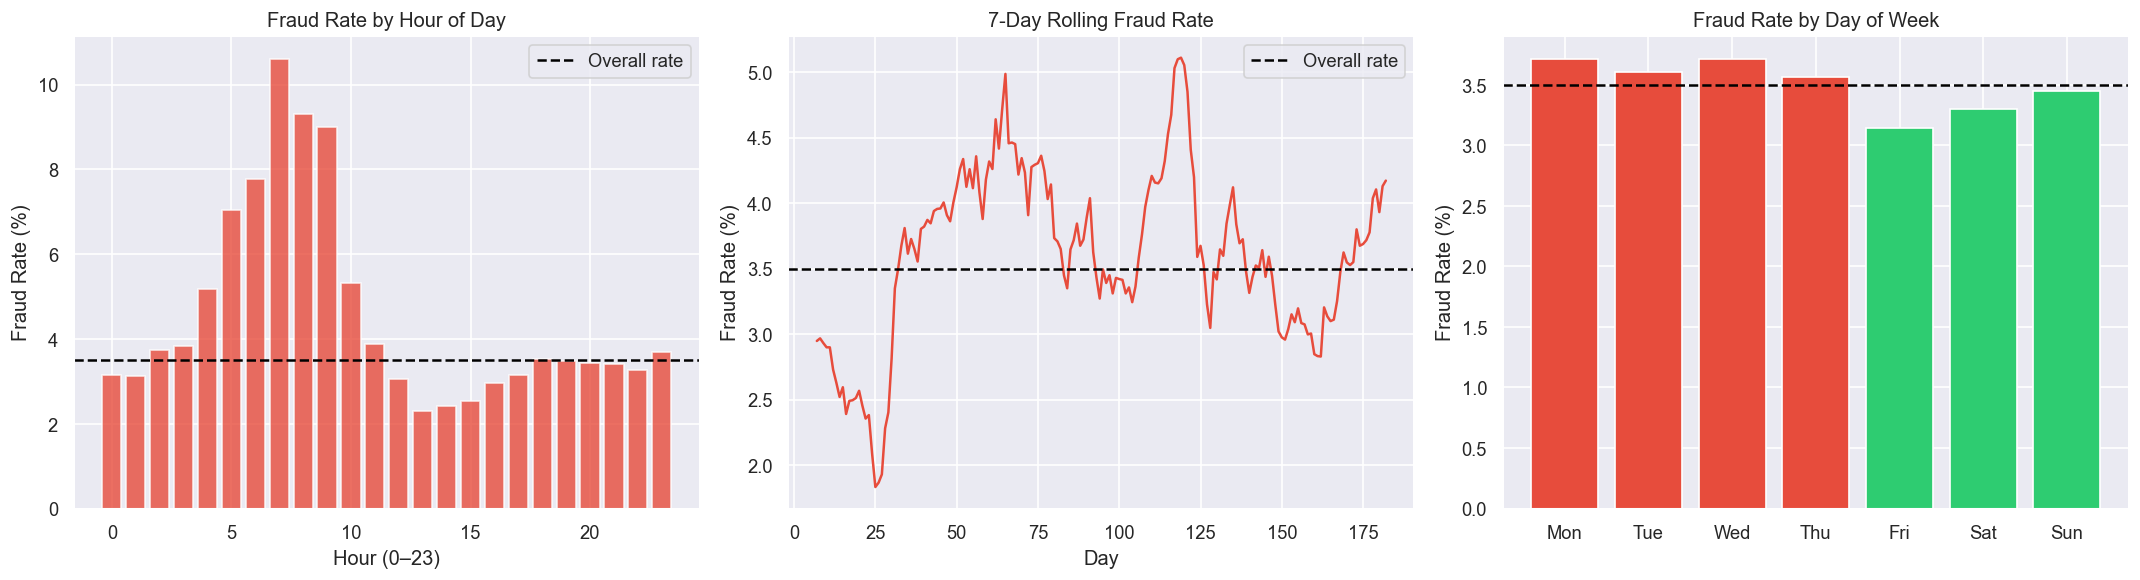

In [6]:
df['tx_hour'] = (df['TransactionDT'] / 3600) % 24
df['tx_day_of_week'] = (df['TransactionDT'] / 86400).astype(int) % 7
df['tx_day'] = (df['TransactionDT'] / 86400).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Hourly fraud rate
hourly = df.groupby(df['tx_hour'].astype(int))['isFraud'].mean()
axes[0].bar(hourly.index, hourly.values * 100, color='#e74c3c', alpha=0.8)
axes[0].set_title('Fraud Rate by Hour of Day')
axes[0].set_xlabel('Hour (0–23)')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].axhline(fraud_rate * 100, color='black', linestyle='--', label='Overall rate')
axes[0].legend()

# Daily fraud rate over time
daily = df.groupby('tx_day')['isFraud'].mean().rolling(7).mean()
axes[1].plot(daily.index, daily.values * 100, color='#e74c3c')
axes[1].set_title('7-Day Rolling Fraud Rate')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].axhline(fraud_rate * 100, color='black', linestyle='--', label='Overall rate')
axes[1].legend()

# Day-of-week fraud rate
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow = df.groupby('tx_day_of_week')['isFraud'].mean()
axes[2].bar([day_names[i % 7] for i in dow.index], dow.values * 100,
            color=['#e74c3c' if v > fraud_rate else '#2ecc71' for v in dow.values])
axes[2].set_title('Fraud Rate by Day of Week')
axes[2].set_ylabel('Fraud Rate (%)')
axes[2].axhline(fraud_rate * 100, color='black', linestyle='--')

plt.tight_layout()
plt.show()

## 4. Missing Value Analysis

Columns with >50% missing: 214
Columns with any missing:  414


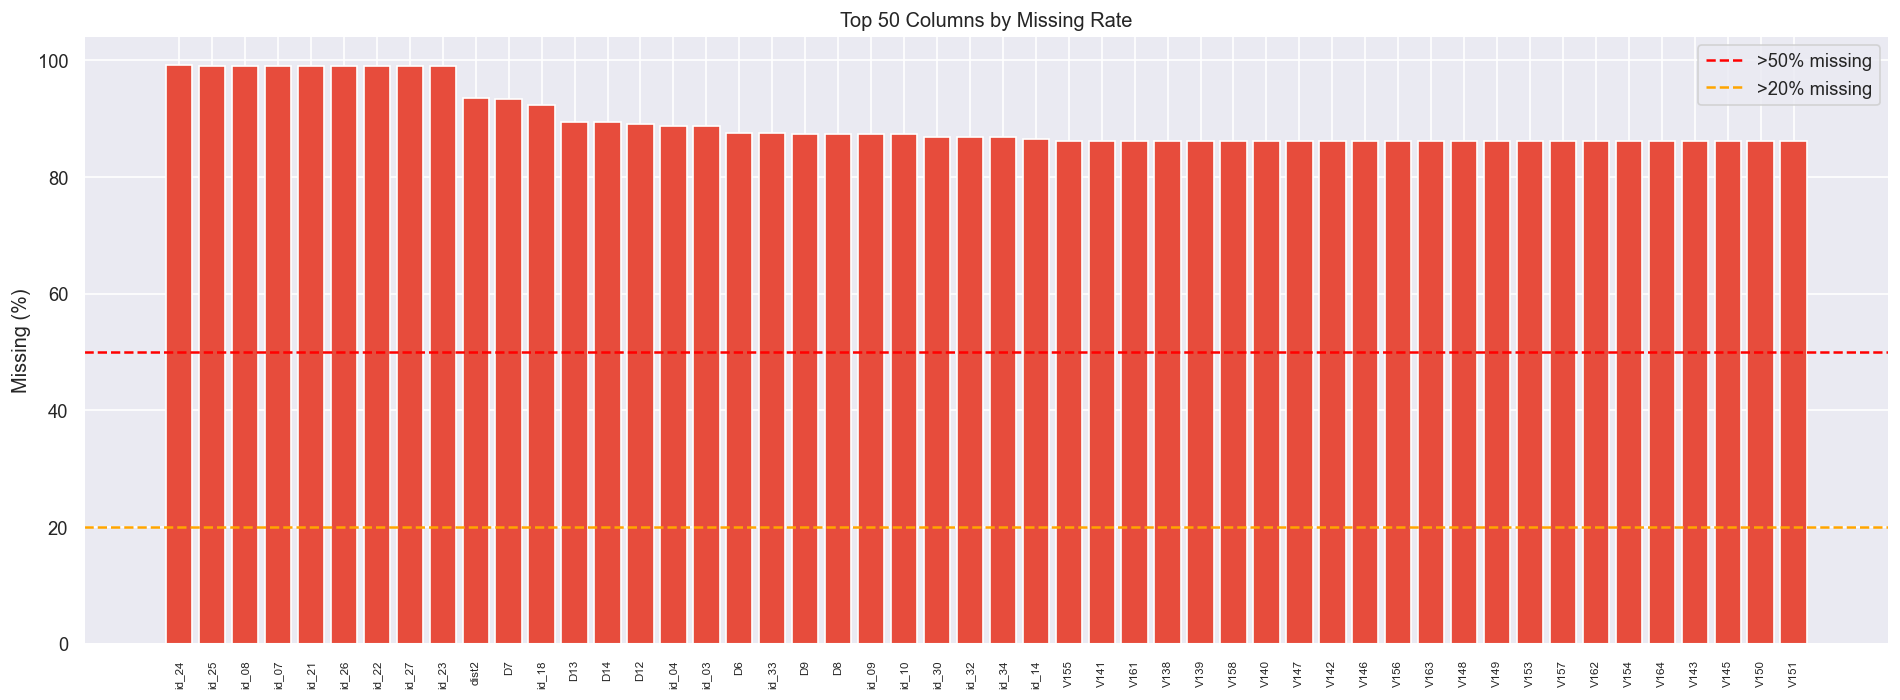

In [7]:
missing = df.isnull().mean().sort_values(ascending=False)
high_missing = missing[missing > 0.5]
print(f'Columns with >50% missing: {len(high_missing)}')
print(f'Columns with any missing:  {(missing > 0).sum()}')

fig, ax = plt.subplots(figsize=(16, 6))
top_missing = missing.head(50)
colors = ['#e74c3c' if v > 0.5 else '#f39c12' if v > 0.2 else '#3498db'
          for v in top_missing.values]
ax.bar(range(len(top_missing)), top_missing.values * 100, color=colors)
ax.set_xticks(range(len(top_missing)))
ax.set_xticklabels(top_missing.index, rotation=90, fontsize=7)
ax.axhline(50, color='red', linestyle='--', label='>50% missing')
ax.axhline(20, color='orange', linestyle='--', label='>20% missing')
ax.set_ylabel('Missing (%)')
ax.set_title('Top 50 Columns by Missing Rate')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Categorical Feature Fraud Rates

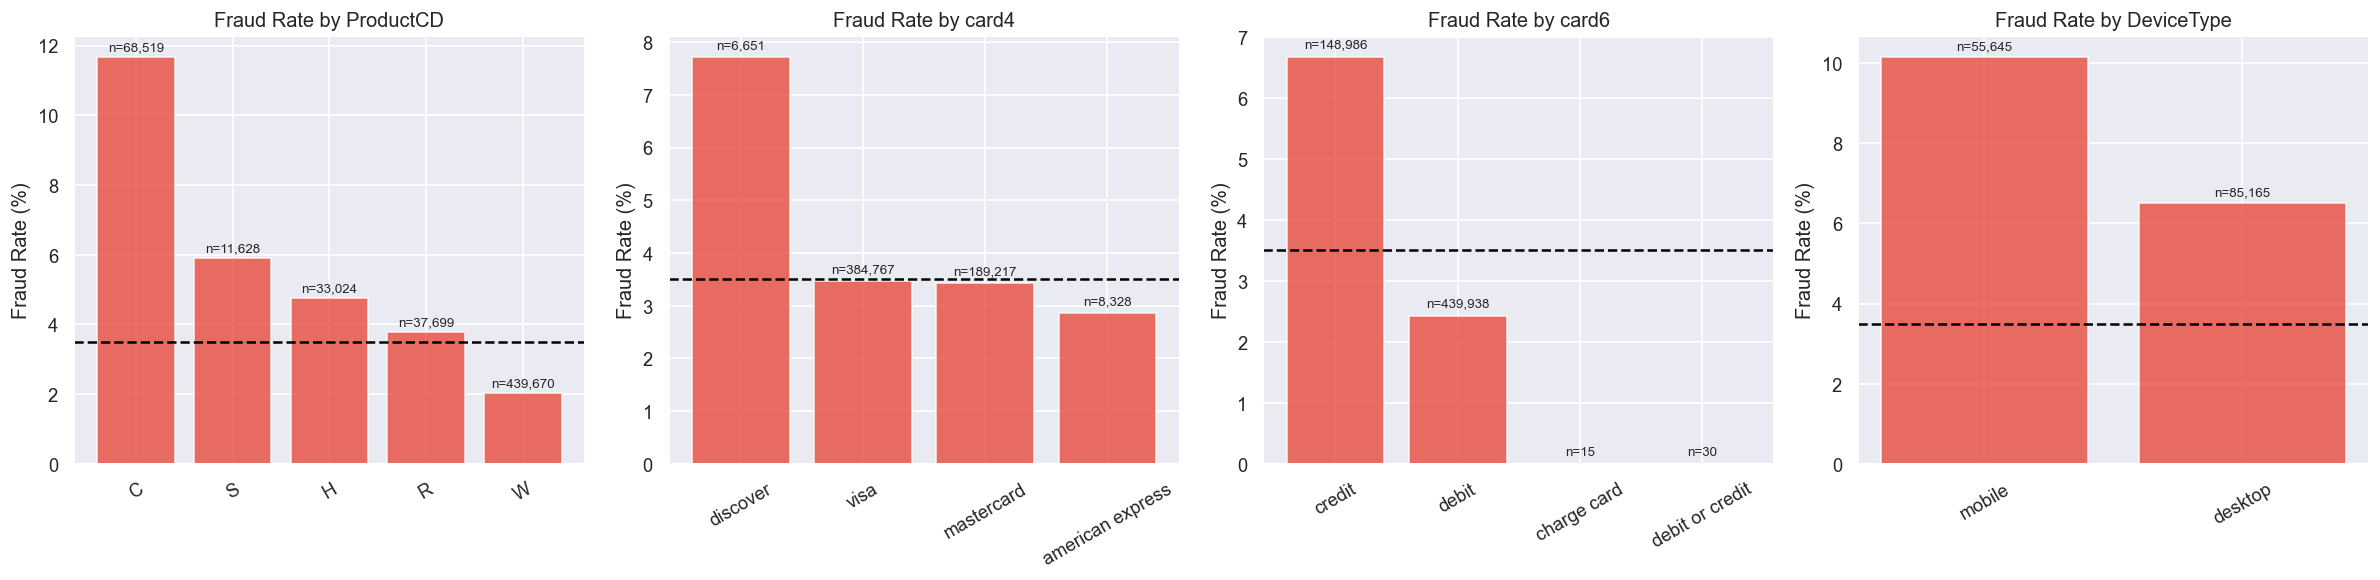

In [8]:
cat_cols = ['ProductCD', 'card4', 'card6', 'DeviceType']
existing_cats = [c for c in cat_cols if c in df.columns]

fig, axes = plt.subplots(1, len(existing_cats), figsize=(5 * len(existing_cats), 5))
if len(existing_cats) == 1:
    axes = [axes]

for ax, col in zip(axes, existing_cats):
    fraud_by_cat = df.groupby(col)['isFraud'].agg(['mean', 'count']).reset_index()
    fraud_by_cat = fraud_by_cat.sort_values('mean', ascending=False)
    bars = ax.bar(fraud_by_cat[col].astype(str), fraud_by_cat['mean'] * 100,
                  color='#e74c3c', alpha=0.8)
    ax.axhline(fraud_rate * 100, color='black', linestyle='--', linewidth=1.5)
    ax.set_title(f'Fraud Rate by {col}')
    ax.set_ylabel('Fraud Rate (%)')
    ax.tick_params(axis='x', rotation=30)
    for bar, (_, row) in zip(bars, fraud_by_cat.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.1,
                f"n={int(row['count']):,}",
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## 6. Device-Sharing Analysis (Key Fraud Signal)

Total unique devices: 1,786
Devices used by >1 card: 1,237
Devices used by >5 cards: 560


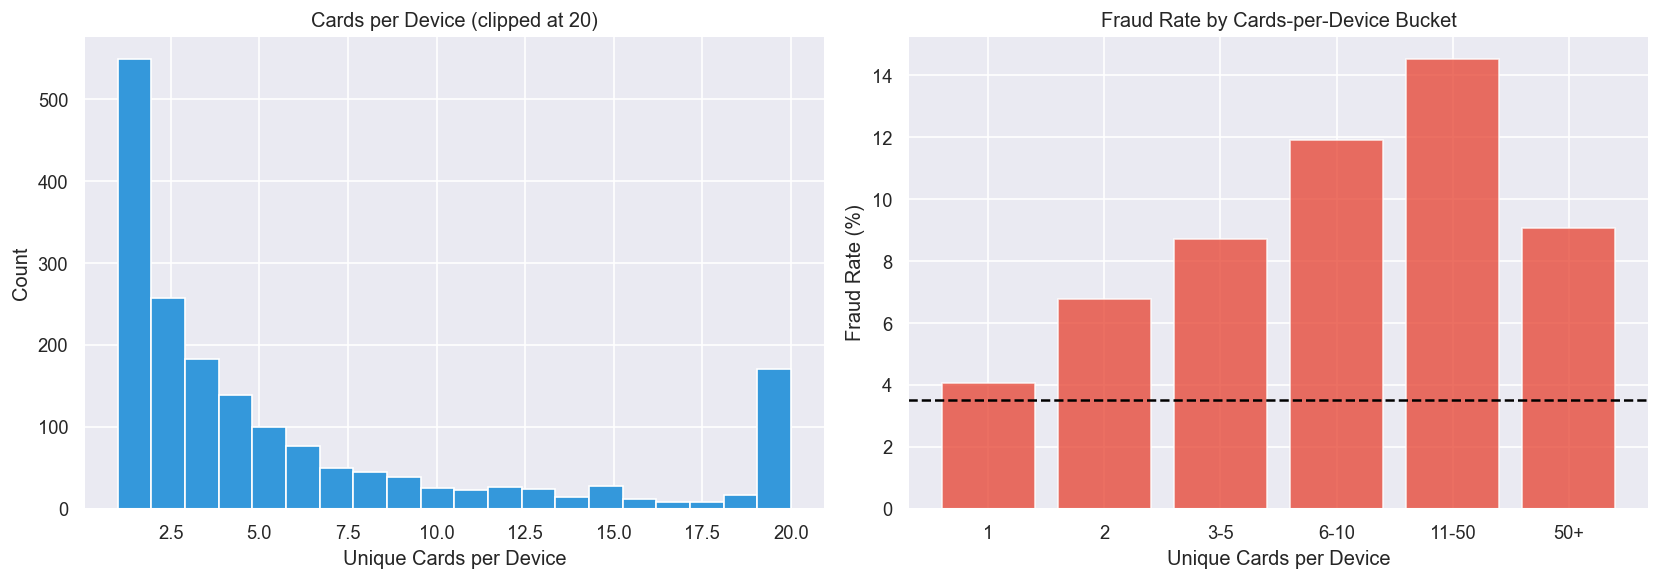

In [9]:
if 'DeviceInfo' in df.columns:
    # Count unique cards per device
    device_stats = df.groupby('DeviceInfo').agg(
        n_cards=('card1', 'nunique'),
        n_transactions=('TransactionID', 'count'),
        fraud_rate=('isFraud', 'mean')
    ).reset_index()

    print(f'Total unique devices: {device_stats["DeviceInfo"].nunique():,}')
    print(f'Devices used by >1 card: {(device_stats["n_cards"] > 1).sum():,}')
    print(f'Devices used by >5 cards: {(device_stats["n_cards"] > 5).sum():,}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Distribution of cards per device
    device_stats['n_cards'].clip(upper=20).hist(bins=20, ax=axes[0], color='#3498db', edgecolor='white')
    axes[0].set_title('Cards per Device (clipped at 20)')
    axes[0].set_xlabel('Unique Cards per Device')
    axes[0].set_ylabel('Count')

    # Fraud rate vs number of cards per device
    device_stats['card_bucket'] = pd.cut(device_stats['n_cards'],
                                          bins=[0,1,2,5,10,50,1000],
                                          labels=['1','2','3-5','6-10','11-50','50+'])
    bucket_fraud = device_stats.groupby('card_bucket')['fraud_rate'].mean()
    axes[1].bar(bucket_fraud.index.astype(str), bucket_fraud.values * 100,
                color='#e74c3c', alpha=0.8)
    axes[1].axhline(fraud_rate * 100, color='black', linestyle='--')
    axes[1].set_title('Fraud Rate by Cards-per-Device Bucket')
    axes[1].set_xlabel('Unique Cards per Device')
    axes[1].set_ylabel('Fraud Rate (%)')

    plt.tight_layout()
    plt.show()

## 7. Correlation Heatmap (Key Numeric Features)

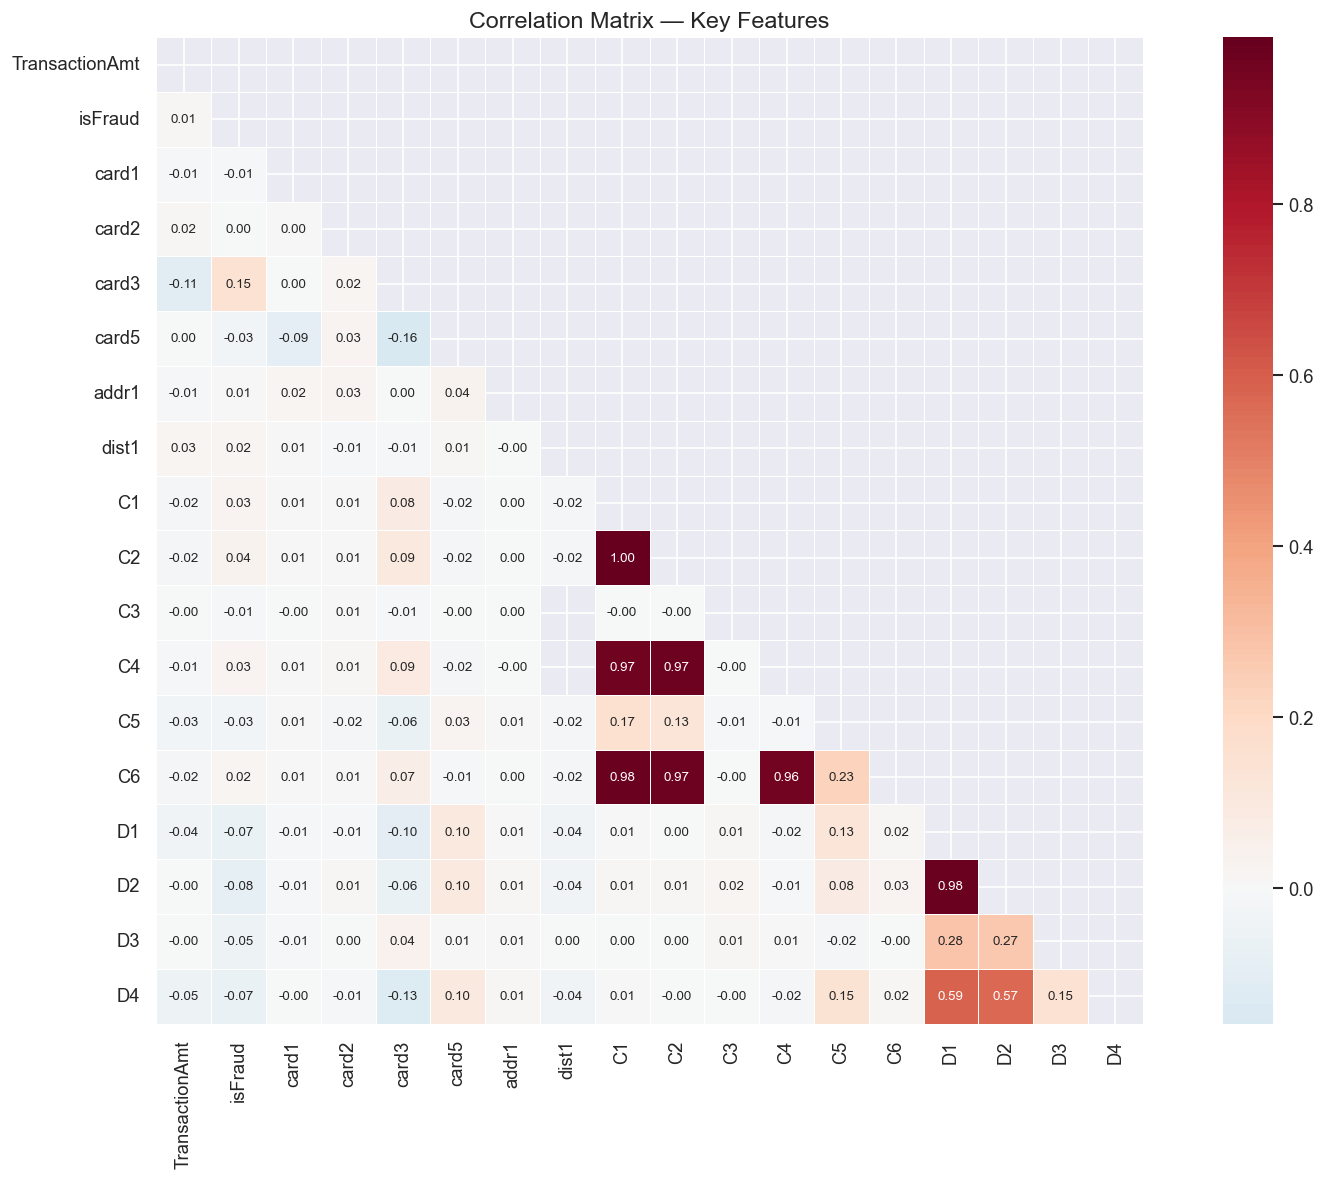

In [10]:
key_features = [
    'TransactionAmt', 'isFraud',
    'card1', 'card2', 'card3', 'card5',
    'addr1', 'dist1',
    'C1', 'C2', 'C3', 'C4', 'C5', 'C6',
    'D1', 'D2', 'D3', 'D4',
]
available = [c for c in key_features if c in df.columns]
corr = df[available].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 8},
            square=True, linewidths=0.5)
plt.title('Correlation Matrix — Key Features', fontsize=14)
plt.tight_layout()
plt.show()

## 8. EDA Summary

In [11]:
print("="*60)
print("EDA KEY FINDINGS")
print("="*60)
print(f"\n1. Dataset: {len(df):,} transactions, {df.shape[1]} features")
print(f"   Fraud rate: {fraud_rate:.4%} (severe imbalance)")
print(f"\n2. Missing values: {(df.isnull().mean() > 0.5).sum()} columns > 50% missing")
print(f"   Strategy: median imputation for numeric, 'Unknown' for categorical")
print(f"\n3. Fraud transactions have higher amounts:")
print(f"   Legitimate median: ${df[df['isFraud']==0]['TransactionAmt'].median():.2f}")
print(f"   Fraud median:      ${df[df['isFraud']==1]['TransactionAmt'].median():.2f}")
print(f"\n4. Device-sharing is a strong fraud signal:")
if 'DeviceInfo' in df.columns:
    high_device = df.groupby('DeviceInfo')['card1'].nunique()
    df_merged = df.join(high_device.rename('dev_card_count'), on='DeviceInfo')
    fraud_high_device = df_merged[df_merged['dev_card_count'] > 5]['isFraud'].mean()
    print(f"   Fraud rate (>5 cards/device): {fraud_high_device:.4%}")
    print(f"   vs overall: {fraud_rate:.4%}")
print(f"\n5. Fraud peaks at night hours (22:00 – 06:00)")
print(f"   → Feature: tx_is_night")
print(f"\n6. Graph-based features will capture coordinated fraud rings")
print("="*60)

EDA KEY FINDINGS

1. Dataset: 590,540 transactions, 437 features
   Fraud rate: 3.4990% (severe imbalance)

2. Missing values: 214 columns > 50% missing
   Strategy: median imputation for numeric, 'Unknown' for categorical

3. Fraud transactions have higher amounts:
   Legitimate median: $68.50
   Fraud median:      $75.00

4. Device-sharing is a strong fraud signal:
   Fraud rate (>5 cards/device): 7.1928%
   vs overall: 3.4990%

5. Fraud peaks at night hours (22:00 – 06:00)
   → Feature: tx_is_night

6. Graph-based features will capture coordinated fraud rings
